# Etap 4 — Optymalizacja modelu

## 1. Baseline — Random Forest bez optymalizacji

In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

df = pd.read_csv('data/processed/final_datasets/knn_std.csv')
X = df.drop('Result', axis=1)
y = df['Result']
print(f"Wymiary zbioru: {X.shape}, cech: {X.shape[1]}")
print(f"Rozklad klas: {dict(y.value_counts())}")

def manual_train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    y_arr = np.array(y)
    train_idx, test_idx = [], []
    for cls in np.unique(y_arr):
        cls_idx = np.where(y_arr == cls)[0]
        np.random.shuffle(cls_idx)
        k = int(len(cls_idx) * test_size)
        test_idx.extend(cls_idx[:k])
        train_idx.extend(cls_idx[k:])
    train_idx, test_idx = np.array(train_idx), np.array(test_idx)
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)
    return (X.iloc[train_idx].reset_index(drop=True),
            X.iloc[test_idx].reset_index(drop=True),
            y.iloc[train_idx].reset_index(drop=True),
            y.iloc[test_idx].reset_index(drop=True))

X_train, X_test, y_train, y_test = manual_train_test_split(X, y, test_size=0.2)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
baseline_cv_f1 = cv_scores.mean()
baseline_cv_std = cv_scores.std()

baseline_model.fit(X_train, y_train)
from sklearn.metrics import f1_score
baseline_test_preds = baseline_model.predict(X_test)
baseline_test_f1 = f1_score(y_test, baseline_test_preds)

print(f"\n=== BASELINE: Random Forest (domyslne parametry) ===")
print(f"CV F1 (5-fold):  {baseline_cv_f1:.4f} +/- {baseline_cv_std:.4f}")
print(f"Test F1:         {baseline_test_f1:.4f}")
print(f"Liczba cech:     {X.shape[1]}")

results_summary = {
    'Baseline (default RF)': {
        'cv_f1_mean': round(baseline_cv_f1, 4),
        'cv_f1_std': round(baseline_cv_std, 4),
        'test_f1': round(baseline_test_f1, 4),
        'n_features': X.shape[1],
        'params': 'domyslne',
    }
}


Wymiary zbioru: (11055, 20), cech: 20
Rozklad klas: {1: np.int64(6157), -1: np.int64(4898)}

Train: (8845, 20), Test: (2210, 20)

=== BASELINE: Random Forest (domyslne parametry) ===
CV F1 (5-fold):  0.9496 +/- 0.0036
Test F1:         0.9447
Liczba cech:     20


## 2. Optymalizacja cech

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import matplotlib.pyplot as plt
import seaborn as sns

k_values = [5, 10, 15, 20, X_train.shape[1]]
kbest_results = []

for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)
    X_tr_sel = selector.fit_transform(X_train, y_train)
    cv_f1 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                             X_tr_sel, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    kbest_results.append({'k': k, 'cv_f1': round(cv_f1, 4),
                          'features': list(X_train.columns[selector.get_support()])})

kbest_df = pd.DataFrame([{'k': r['k'], 'cv_f1': r['cv_f1']} for r in kbest_results])
print("=== SelectKBest - wynik dla roznych k ===")
display(kbest_df)

best_k_idx = kbest_df['cv_f1'].idxmax()
best_k = kbest_df.loc[best_k_idx, 'k']
kbest_features = kbest_results[best_k_idx]['features']
print(f"\nNajlepsze k: {best_k} (CV F1 = {kbest_df.loc[best_k_idx, 'cv_f1']})")
print(f"Wybrane cechy: {kbest_features}")

rfe_results = []
for n in [10, 15, 20]:
    rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
              n_features_to_select=n, step=1)
    rfe.fit(X_train, y_train)
    X_tr_sel = rfe.transform(X_train)
    cv_f1 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                             X_tr_sel, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    rfe_results.append({'n': n, 'cv_f1': round(cv_f1, 4),
                        'features': list(X_train.columns[rfe.support_])})

rfe_df = pd.DataFrame([{'n_features': r['n'], 'cv_f1': r['cv_f1']} for r in rfe_results])
print("\n=== RFE - wynik dla roznych n_features ===")
display(rfe_df)

best_rfe_idx = rfe_df['cv_f1'].idxmax()
best_n = rfe_df.loc[best_rfe_idx, 'n_features']
rfe_features = rfe_results[best_rfe_idx]['features']
print(f"\nNajlepsze n_features: {best_n} (CV F1 = {rfe_df.loc[best_rfe_idx, 'cv_f1']})")
print(f"Wybrane cechy: {rfe_features}")

if kbest_df['cv_f1'].max() >= rfe_df['cv_f1'].max():
    best_features = kbest_features
    print(f"\nWybor: SelectKBest (k={best_k})")
else:
    best_features = rfe_features
    print(f"\nWybor: RFE (n={best_n})")

print(f"Finalna liczba cech: {len(best_features)}")

X_train_sel = X_train[best_features]
X_test_sel = X_test[best_features]

model_after_fs = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores_fs = cross_val_score(model_after_fs, X_train_sel, y_train, cv=cv, scoring='f1', n_jobs=-1)
model_after_fs.fit(X_train_sel, y_train)
test_f1_fs = f1_score(y_test, model_after_fs.predict(X_test_sel))

print(f"\n=== Po selekcji cech ===")
print(f"CV F1: {cv_scores_fs.mean():.4f} +/- {cv_scores_fs.std():.4f}")
print(f"Test F1: {test_f1_fs:.4f}")

results_summary['Feature selection (SelectKBest/RFE)'] = {
    'cv_f1_mean': round(cv_scores_fs.mean(), 4),
    'cv_f1_std': round(cv_scores_fs.std(), 4),
    'test_f1': round(test_f1_fs, 4),
    'n_features': len(best_features),
    'params': f'best of SelectKBest k={best_k} vs RFE n={best_n}',
}


=== SelectKBest - wynik dla roznych k ===


,k,cv_f1
0,5,0.9271
1,10,0.9375
2,15,0.9480
3,20,0.9496
4,20,0.9496



Najlepsze k: 20 (CV F1 = 0.9496)
Wybrane cechy: ['SSLfinal_State', 'URL_of_Anchor', 'web_traffic', 'Prefix_Suffix', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Domain_registeration_length', 'SFH', 'URL_Risk_Score', 'age_of_domain', 'Google_Index', 'Page_Rank', 'having_IP_Address', 'Statistical_report', 'DNSRecord', 'Shortining_Service', 'Abnormal_URL', 'URL_Length', 'having_At_Symbol']

=== RFE - wynik dla roznych n_features ===


,n_features,cv_f1
0,10,0.9439
1,15,0.9470
2,20,0.9496



Najlepsze n_features: 20 (CV F1 = 0.9496)
Wybrane cechy: ['SSLfinal_State', 'URL_of_Anchor', 'web_traffic', 'Prefix_Suffix', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Domain_registeration_length', 'SFH', 'URL_Risk_Score', 'age_of_domain', 'Google_Index', 'Page_Rank', 'having_IP_Address', 'Statistical_report', 'DNSRecord', 'Shortining_Service', 'Abnormal_URL', 'URL_Length', 'having_At_Symbol']

Wybor: SelectKBest (k=20)
Finalna liczba cech: 20

=== Po selekcji cech ===
CV F1: 0.9496 +/- 0.0036
Test F1: 0.9447


## 3. Grid Search — wyczerpujące przeszukiwanie siatki (na 3.0–4.0)

In [12]:
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"Siatka: {total_combos} kombinacji x 5-fold CV = {total_combos*5} fitow")

t0 = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_sel, y_train)
elapsed_grid = time.time() - t0
print(f"\nCzas: {elapsed_grid:.1f}s")

print(f"\n=== Grid Search wynik ===")
print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy CV F1: {grid_search.best_score_:.4f}")

grid_test_f1 = f1_score(y_test, grid_search.best_estimator_.predict(X_test_sel))
print(f"Test F1: {grid_test_f1:.4f}")

results_summary['Grid Search'] = {
    'cv_f1_mean': round(grid_search.best_score_, 4),
    'cv_f1_std': 0.0,
    'test_f1': round(grid_test_f1, 4),
    'n_features': len(best_features),
    'params': str(grid_search.best_params_),
    'time_s': round(elapsed_grid, 1),
}


Siatka: 16 kombinacji x 5-fold CV = 80 fitow
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Czas: 7.9s

=== Grid Search wynik ===
Najlepsze parametry: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Najlepszy CV F1: 0.9502
Test F1: 0.9430


## 4. Optuna — bayesowska optymalizacja TPE (na 4.0–4.5)

Czas: 43.0s

=== Optuna wynik ===
Najlepsze parametry: {'n_estimators': 350, 'max_depth': 26, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.12062449786877341}
Najlepszy CV F1: 0.9516
Test F1: 0.9476


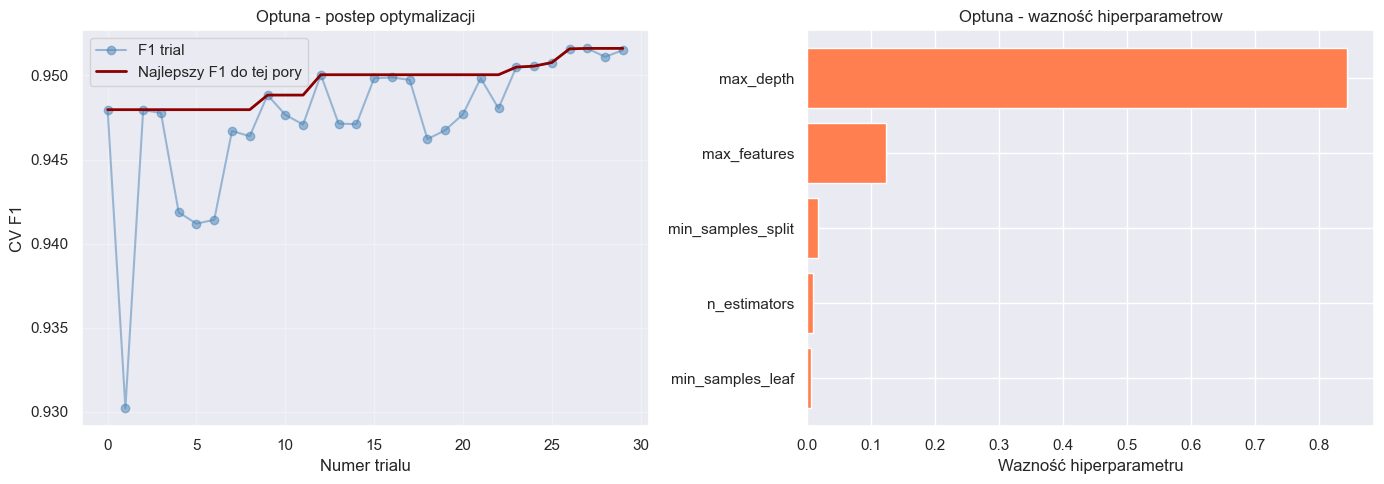

In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 30  # zwieksz do 100+ dla dokladniejszej optymalizacji

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=1)
    return cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()

t0 = time.time()
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
elapsed_optuna = time.time() - t0
print(f"Czas: {elapsed_optuna:.1f}s")

print(f"\n=== Optuna wynik ===")
print(f"Najlepsze parametry: {study.best_params}")
print(f"Najlepszy CV F1: {study.best_value:.4f}")

optuna_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
optuna_model.fit(X_train_sel, y_train)
optuna_test_f1 = f1_score(y_test, optuna_model.predict(X_test_sel))
print(f"Test F1: {optuna_test_f1:.4f}")

results_summary['Optuna (TPE)'] = {
    'cv_f1_mean': round(study.best_value, 4),
    'cv_f1_std': 0.0,
    'test_f1': round(optuna_test_f1, 4),
    'n_features': len(best_features),
    'params': str(study.best_params),
    'time_s': round(elapsed_optuna, 1),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df.index, trials_df['value'], 'o-', alpha=0.5, color='steelblue', label='F1 trial')
axes[0].plot(trials_df.index, trials_df['value'].cummax(), '-', color='darkred', linewidth=2, label='Najlepszy F1 do tej pory')
axes[0].set_xlabel('Numer trialu')
axes[0].set_ylabel('CV F1')
axes[0].set_title('Optuna - postep optymalizacji')
axes[0].legend()
axes[0].grid(alpha=0.3)

try:
    importance = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importance.keys()), list(importance.values()), color='coral')
    axes[1].set_xlabel('Wazność hiperparametru')
    axes[1].set_title('Optuna - wazność hiperparametrow')
    axes[1].invert_yaxis()
except Exception as e:
    axes[1].text(0.5, 0.5, f'(importance nie dziala: {str(e)[:50]})', ha='center', va='center')

plt.tight_layout()
plt.show()


## 5. Algorytm genetyczny (na 5.0)

Czas: 147.5s

=== Algorytm genetyczny wynik ===
Najlepsze parametry: {'n_estimators': 389, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': np.float64(0.13350934442434376)}
Najlepszy CV F1: 0.9519
Test F1: 0.9489


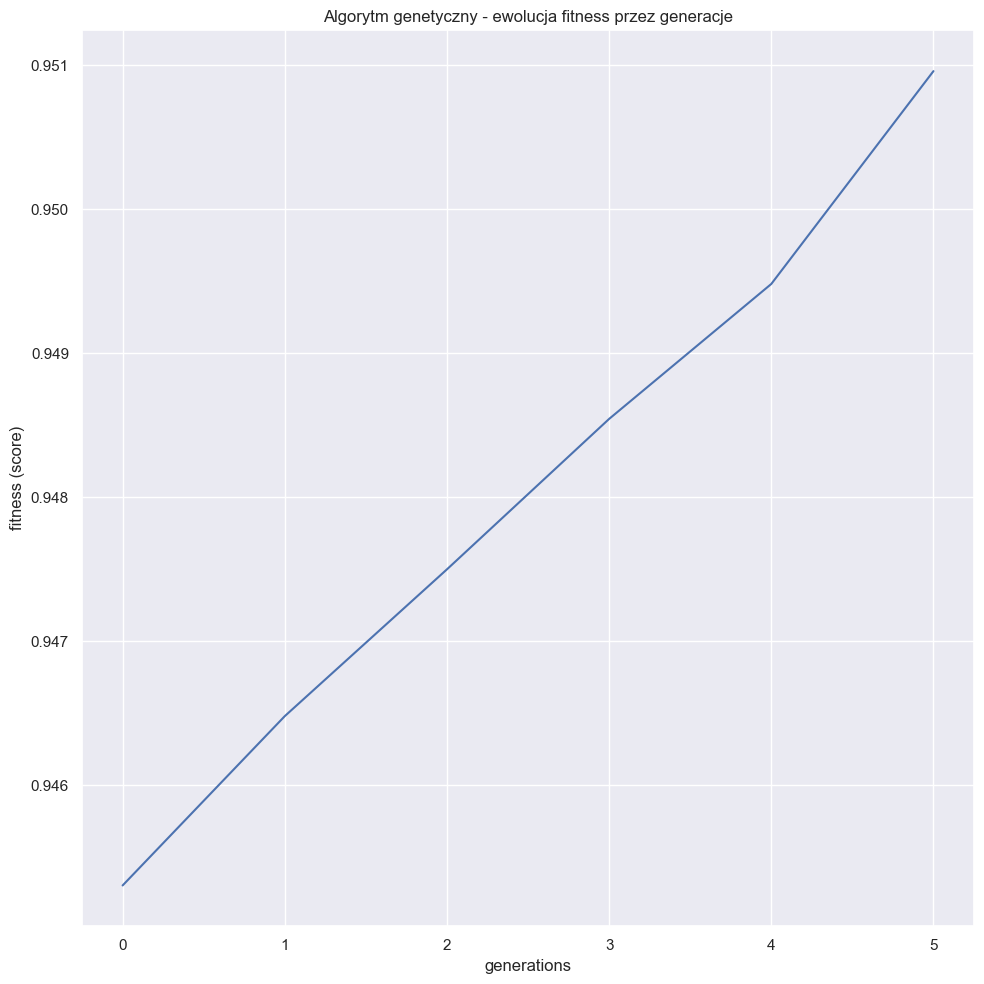

In [14]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Integer, Continuous, Categorical

param_grid_ga = {
    'n_estimators': Integer(100, 400),
    'max_depth': Integer(5, 30),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Continuous(0.1, 1.0),
}

t0 = time.time()

ga_search = GASearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    cv=cv,
    scoring='f1',
    param_grid=param_grid_ga,
    n_jobs=-1,
    verbose=False,
    population_size=10,  # zwieksz do 20-30
    generations=5,       # zwieksz do 10-20
    crossover_probability=0.8,
    mutation_probability=0.1,
    keep_top_k=4,
    elitism=True,
    return_train_score=False,
)
ga_search.fit(X_train_sel, y_train)
elapsed_ga = time.time() - t0
print(f"Czas: {elapsed_ga:.1f}s")

print(f"\n=== Algorytm genetyczny wynik ===")
print(f"Najlepsze parametry: {ga_search.best_params_}")
print(f"Najlepszy CV F1: {ga_search.best_score_:.4f}")

ga_test_f1 = f1_score(y_test, ga_search.best_estimator_.predict(X_test_sel))
print(f"Test F1: {ga_test_f1:.4f}")

results_summary['Algorytm genetyczny'] = {
    'cv_f1_mean': round(ga_search.best_score_, 4),
    'cv_f1_std': 0.0,
    'test_f1': round(ga_test_f1, 4),
    'n_features': len(best_features),
    'params': str(ga_search.best_params_),
    'time_s': round(elapsed_ga, 1),
}

try:
    from sklearn_genetic.plots import plot_fitness_evolution
    plot_fitness_evolution(ga_search)
    plt.title('Algorytm genetyczny - ewolucja fitness przez generacje')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(plot_fitness_evolution: {e})")


## 6. AutoML — H2O AutoML

In [15]:
import h2o
from h2o.automl import H2OAutoML

print("Uruchamianie H2O AutoML...")
h2o.init(verbose=False)

train_df = pd.concat([X_train_sel, y_train], axis=1)
test_df = pd.concat([X_test_sel, y_test], axis=1)
train_h2o = h2o.H2OFrame(train_df)
test_h2o = h2o.H2OFrame(test_df)

target = 'Result'
features_list = [c for c in train_h2o.columns if c != target]
train_h2o[target] = train_h2o[target].asfactor()
test_h2o[target] = test_h2o[target].asfactor()

t0 = time.time()

aml = H2OAutoML(
    max_runtime_secs=120,    # 2 min - zwieksz do 600+ dla pelnej optymalizacji !!!!!
    seed=42,
    max_models=15,
    sort_metric='AUC',
    nfolds=5,
)
aml.train(x=features_list, y=target, training_frame=train_h2o)
elapsed_automl = time.time() - t0
print(f"Czas: {elapsed_automl:.1f}s")

print("\n=== H2O AutoML Leaderboard (top 10) ===")
leaderboard_df = aml.leaderboard.as_data_frame()
display(leaderboard_df.head(10))

best_model = aml.leader
print(f"\nNajlepszy model: {best_model.model_id}")

preds_h2o = best_model.predict(test_h2o)
preds_df = preds_h2o.as_data_frame()
automl_preds = preds_df['predict'].astype(int).values
automl_test_f1 = f1_score(y_test, automl_preds)
print(f"\nTest F1: {automl_test_f1:.4f}")

h2o.cluster().shutdown()

results_summary['H2O AutoML'] = {
    'cv_f1_mean': 0.0,
    'cv_f1_std': 0.0,
    'test_f1': round(automl_test_f1, 4),
    'n_features': len(best_features),
    'params': f'H2O leader: {best_model.model_id}',
    'time_s': round(elapsed_automl, 1),
}


Uruchamianie H2O AutoML...
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
22:25:29.880: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
Czas: 122.2s

=== H2O AutoML Leaderboard (top 10) ===


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GBM_3_AutoML_1_20260602_222529,0.988595,0.133698,0.990355,0.056693,0.198400,0.039362
1,GBM_grid_1_AutoML_1_20260602_222529_model_3,0.988481,0.134834,0.990343,0.053113,0.198711,0.039486
2,GBM_2_AutoML_1_20260602_222529,0.988232,0.135567,0.989964,0.054670,0.199485,0.039794
3,GBM_4_AutoML_1_20260602_222529,0.988097,0.136447,0.989706,0.054675,0.199446,0.039779
4,GBM_5_AutoML_1_20260602_222529,0.987901,0.137219,0.989688,0.052808,0.200116,0.040046
5,GBM_grid_1_AutoML_1_20260602_222529_model_2,0.987671,0.139940,0.989731,0.057598,0.202714,0.041093
6,GBM_grid_1_AutoML_1_20260602_222529_model_1,0.987539,0.140280,0.989604,0.054186,0.203249,0.041310
7,DRF_1_AutoML_1_20260602_222529,0.987489,0.163199,0.988965,0.055361,0.202659,0.041071
8,GBM_1_AutoML_1_20260602_222529,0.987475,0.140642,0.989611,0.053922,0.202950,0.041189
9,XRT_1_AutoML_1_20260602_222529,0.987284,0.167141,0.988691,0.056386,0.202376,0.040956



Najlepszy model: GBM_3_AutoML_1_20260602_222529
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%

Test F1: 0.9455


## 7. Porównanie wszystkich metod

=== Porownanie wszystkich metod ===


,cv_f1_mean,cv_f1_std,test_f1,n_features,params,time_s
Metoda,,,,,,
Algorytm genetyczny,0.9519,0.0,0.9489,20,"{'n_estimators': 389, 'max_depth': 19, 'min_sa...",147.5
Optuna (TPE),0.9516,0.0,0.9476,20,"{'n_estimators': 350, 'max_depth': 26, 'min_sa...",43.0
H2O AutoML,0.0,0.0,0.9455,20,H2O leader: GBM_3_AutoML_1_20260602_222529,122.2
Baseline (default RF),0.9496,0.0036,0.9447,20,domyslne,NaN
Feature selection (SelectKBest/RFE),0.9496,0.0036,0.9447,20,best of SelectKBest k=20 vs RFE n=20,NaN
Grid Search,0.9502,0.0,0.943,20,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",7.9



=== Zysk wzgledem baseline (Test F1 = 0.9447) ===
  Feature selection (SelectKBest/RFE): +0.00 pp
  Grid Search                        : -0.17 pp
  Optuna (TPE)                       : +0.29 pp
  Algorytm genetyczny                : +0.42 pp
  H2O AutoML                         : +0.08 pp


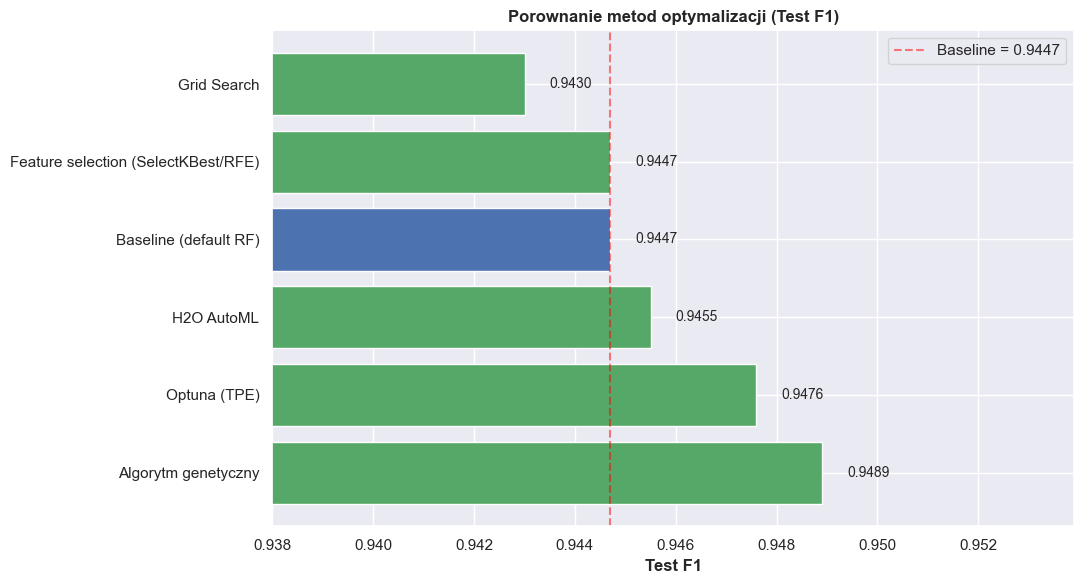

In [16]:
comparison_df = pd.DataFrame(results_summary).T
comparison_df.index.name = 'Metoda'
comparison_df = comparison_df.sort_values(by='test_f1', ascending=False)

print("=== Porownanie wszystkich metod ===")
display(comparison_df)

baseline_f1 = results_summary['Baseline (default RF)']['test_f1']
print(f"\n=== Zysk wzgledem baseline (Test F1 = {baseline_f1}) ===")
for method, res in results_summary.items():
    if method == 'Baseline (default RF)':
        continue
    delta = res['test_f1'] - baseline_f1
    delta_pp = delta * 100
    sign = '+' if delta >= 0 else ''
    print(f"  {method:35s}: {sign}{delta_pp:.2f} pp")

methods = list(comparison_df.index)
test_f1s = comparison_df['test_f1'].astype(float).values

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#4C72B0' if m == 'Baseline (default RF)' else '#55A868' for m in methods]
bars = ax.barh(methods, test_f1s, color=colors)
ax.set_xlabel('Test F1', fontweight='bold')
ax.set_title('Porownanie metod optymalizacji (Test F1)', fontweight='bold')
ax.axvline(baseline_f1, color='red', linestyle='--', alpha=0.5, label=f'Baseline = {baseline_f1}')
ax.set_xlim(min(test_f1s) - 0.005, max(test_f1s) + 0.005)
ax.legend()

for bar, val in zip(bars, test_f1s):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 8. Wyjaśnialność modelu — SHAP + Permutation Importance

Wybrany model do wyjasnialnosci: Algorytm genetyczny (Test F1 = 0.9489)
SHAP shape: (500, 20)
(rzedy = probki, kolumny = cechy)


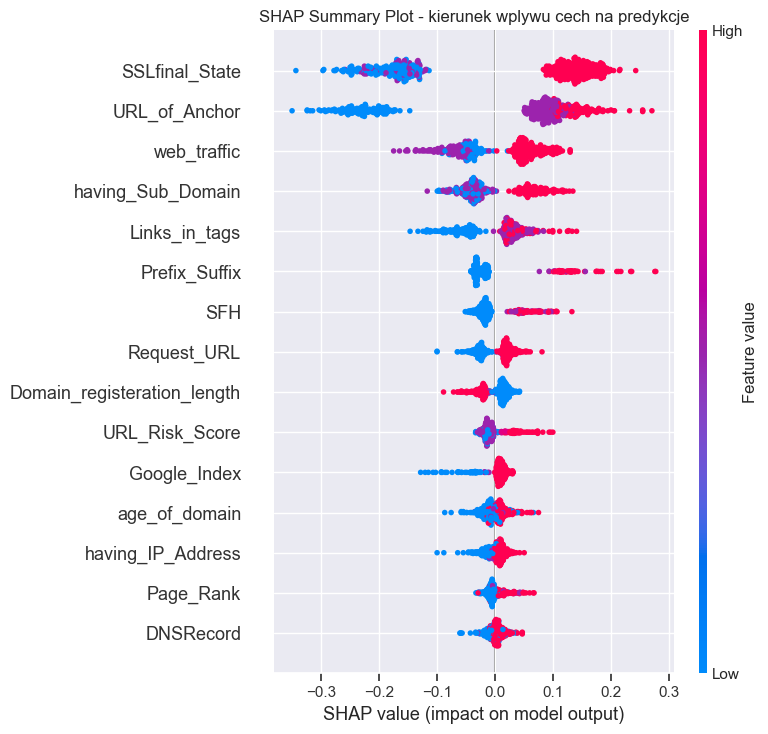

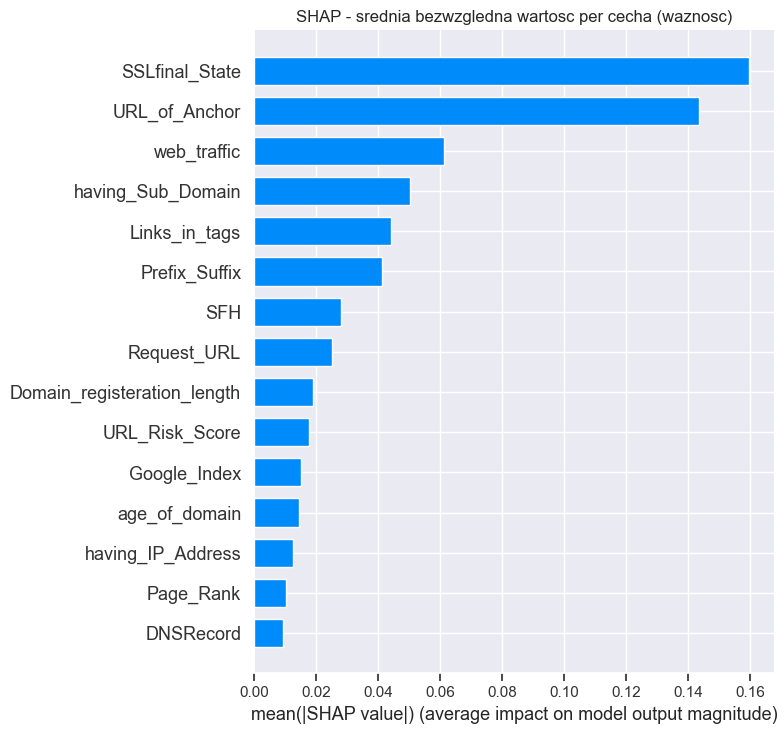


=== Permutation Importance (top 10) ===


,cecha,importance_mean,importance_std
1,URL_of_Anchor,0.106180,0.005943
0,SSLfinal_State,0.078650,0.005592
2,web_traffic,0.014748,0.001517
3,Prefix_Suffix,0.014645,0.003321
6,Links_in_tags,0.014324,0.002417
4,having_Sub_Domain,0.010388,0.001361
10,age_of_domain,0.006662,0.001721
11,Google_Index,0.006498,0.001557
5,Request_URL,0.006223,0.001635
15,DNSRecord,0.006012,0.001419


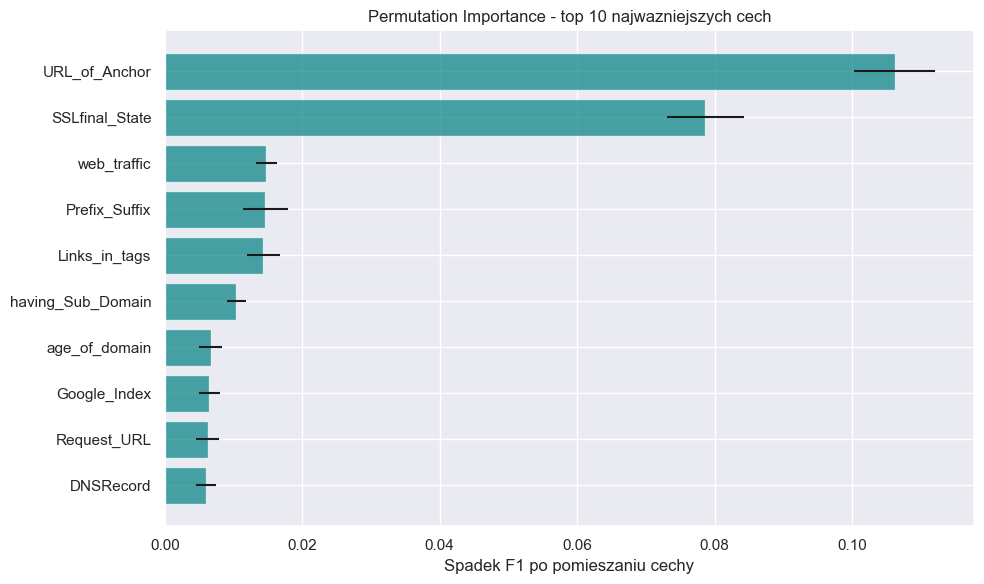

In [17]:
import shap

candidates = {
    'Optuna': optuna_model,
    'Algorytm genetyczny': ga_search.best_estimator_,
    'Grid Search': grid_search.best_estimator_,
}
candidates_f1 = {
    'Optuna': results_summary['Optuna (TPE)']['test_f1'],
    'Algorytm genetyczny': results_summary['Algorytm genetyczny']['test_f1'],
    'Grid Search': results_summary['Grid Search']['test_f1'],
}
best_name = max(candidates_f1, key=candidates_f1.get)
best_model = candidates[best_name]
print(f"Wybrany model do wyjasnialnosci: {best_name} (Test F1 = {candidates_f1[best_name]})")

explainer = shap.TreeExplainer(best_model)

sample_size = min(500, len(X_test_sel))
X_sample = X_test_sel.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print(f"SHAP shape: {shap_values_pos.shape}")
print("(rzedy = probki, kolumny = cechy)")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pos, X_sample, show=False, max_display=15)
plt.title('SHAP Summary Plot - kierunek wplywu cech na predykcje')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pos, X_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP - srednia bezwzgledna wartosc per cecha (waznosc)')
plt.tight_layout()
plt.show()

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(best_model, X_test_sel, y_test,
                                      n_repeats=10, random_state=42, n_jobs=-1, scoring='f1')

perm_df = pd.DataFrame({
    'cecha': X_test_sel.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

print("\n=== Permutation Importance (top 10) ===")
display(perm_df.head(10))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = perm_df.head(10)
ax.barh(top10['cecha'], top10['importance_mean'], xerr=top10['importance_std'],
        color='teal', alpha=0.7)
ax.set_xlabel('Spadek F1 po pomieszaniu cechy')
ax.set_title('Permutation Importance - top 10 najwazniejszych cech')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
